In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/penguin-size-dataset/penguins_size.csv


In [2]:
df= pd.read_csv('/kaggle/input/penguin-size-dataset/penguins_size.csv')

In [3]:
df.shape

(344, 7)

In [4]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [5]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [6]:
df['species'].unique().sum()

'AdelieChinstrapGentoo'

In [7]:
df['island'].unique().sum()

'TorgersenBiscoeDream'

In [8]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Identify string columns
string_cols = df.select_dtypes(include='object').columns

# Apply label encoding only to non-null values
for col in string_cols:
    le = LabelEncoder()
    non_null_mask = df[col].notnull()
    df.loc[non_null_mask, col] = le.fit_transform(df.loc[non_null_mask, col])

print(df.head())


  species island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0       0      2              39.1             18.7              181.0   
1       0      2              39.5             17.4              186.0   
2       0      2              40.3             18.0              195.0   
3       0      2               NaN              NaN                NaN   
4       0      2              36.7             19.3              193.0   

   body_mass_g  sex  
0       3750.0    2  
1       3800.0    1  
2       3250.0    1  
3          NaN  NaN  
4       3450.0    1  


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [9]:
# Fill NaN in numeric columns with their respective column mean
df = df.fillna(df.mean(numeric_only=True))

print(df.head())


  species island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0       0      2          39.10000         18.70000         181.000000   
1       0      2          39.50000         17.40000         186.000000   
2       0      2          40.30000         18.00000         195.000000   
3       0      2          43.92193         17.15117         200.915205   
4       0      2          36.70000         19.30000         193.000000   

   body_mass_g  sex  
0  3750.000000    2  
1  3800.000000    1  
2  3250.000000    1  
3  4201.754386  NaN  
4  3450.000000    1  


In [10]:
# Fill NaN in numeric columns with their respective column mean
df = df.fillna(df.mean(numeric_only=True))

print(df.head())


  species island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0       0      2          39.10000         18.70000         181.000000   
1       0      2          39.50000         17.40000         186.000000   
2       0      2          40.30000         18.00000         195.000000   
3       0      2          43.92193         17.15117         200.915205   
4       0      2          36.70000         19.30000         193.000000   

   body_mass_g  sex  
0  3750.000000    2  
1  3800.000000    1  
2  3250.000000    1  
3  4201.754386  NaN  
4  3450.000000    1  


In [11]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      0
culmen_depth_mm       0
flipper_length_mm     0
body_mass_g           0
sex                  10
dtype: int64

In [12]:
df['sex']=df['sex'].fillna(df['sex'].mode()[0])

/tmp/ipykernel_13/2553488525.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex']=df['sex'].fillna(df['sex'].mode()[0])


In [13]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.10000,18.70000,181.000000,3750.000000,2
1,0,2,39.50000,17.40000,186.000000,3800.000000,1
2,0,2,40.30000,18.00000,195.000000,3250.000000,1
3,0,2,43.92193,17.15117,200.915205,4201.754386,2
4,0,2,36.70000,19.30000,193.000000,3450.000000,1


In [14]:
df.head

<bound method NDFrame.head of     species island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0         0      2          39.10000         18.70000         181.000000   
1         0      2          39.50000         17.40000         186.000000   
2         0      2          40.30000         18.00000         195.000000   
3         0      2          43.92193         17.15117         200.915205   
4         0      2          36.70000         19.30000         193.000000   
..      ...    ...               ...              ...                ...   
339       2      0          43.92193         17.15117         200.915205   
340       2      0          46.80000         14.30000         215.000000   
341       2      0          50.40000         15.70000         222.000000   
342       2      0          45.20000         14.80000         212.000000   
343       2      0          49.90000         16.10000         213.000000   

     body_mass_g  sex  
0    3750.000000    2  
1    3800

In [15]:
df.isnull().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [16]:
df.skew()

species              0.160529
island               0.613949
culmen_length_mm     0.053272
culmen_depth_mm      -0.14388
flipper_length_mm    0.346682
body_mass_g           0.47169
sex                  -0.12619
dtype: object

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


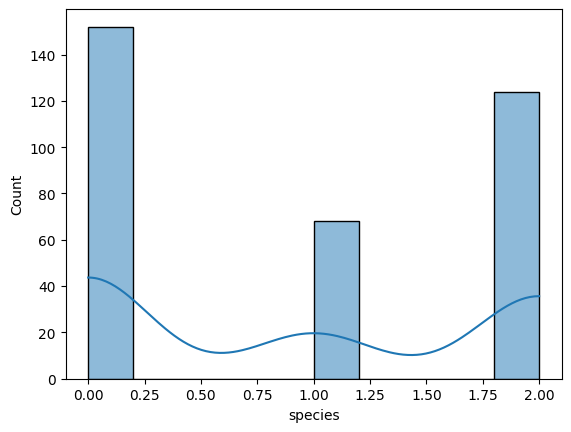

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


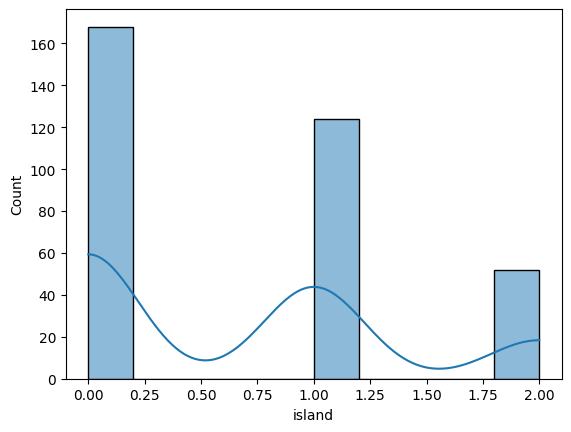

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


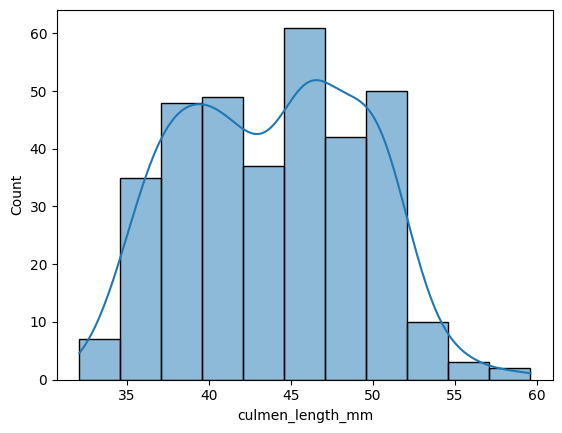

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


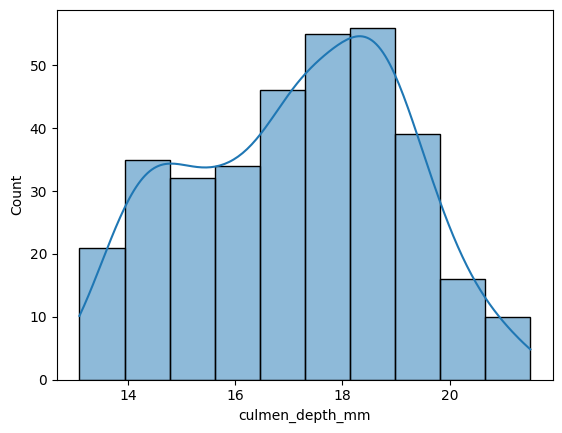

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


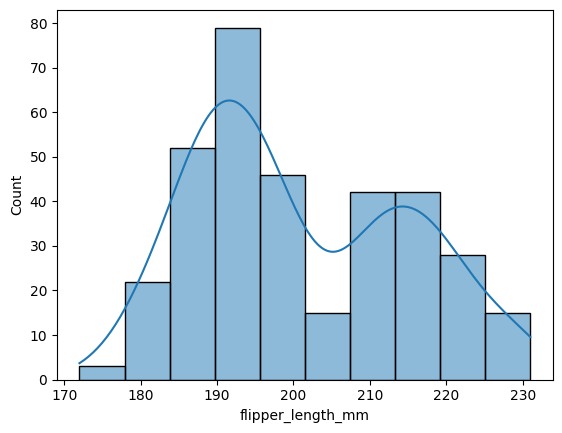

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


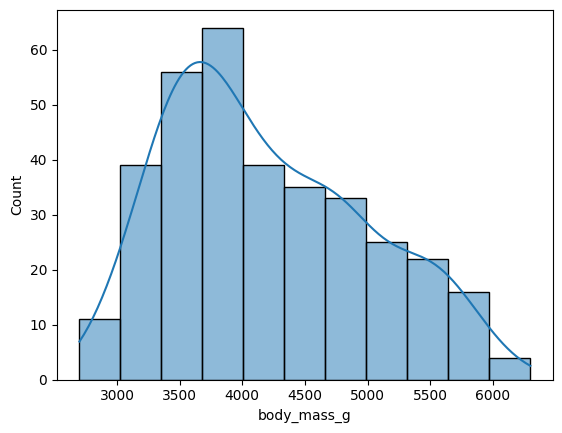

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


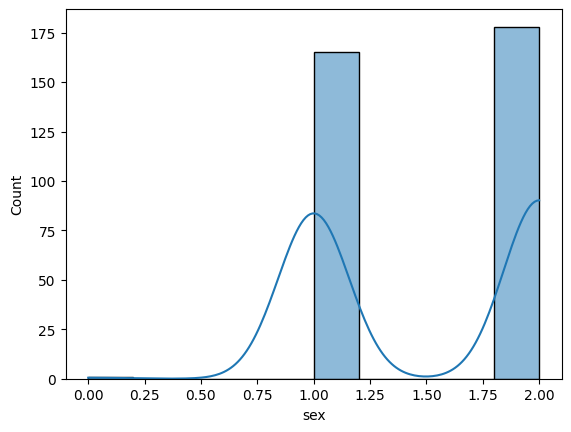

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
col=['species','island','culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g','sex']

for i in col:
    sns.histplot(df[i],kde=True)
    plt.show()

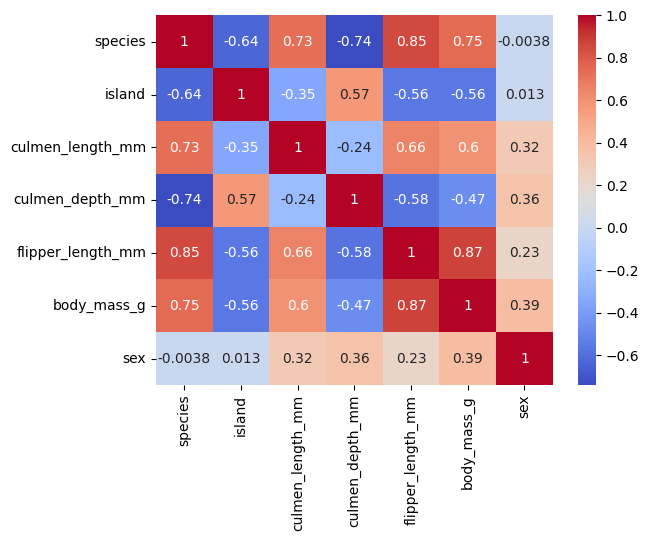

In [18]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

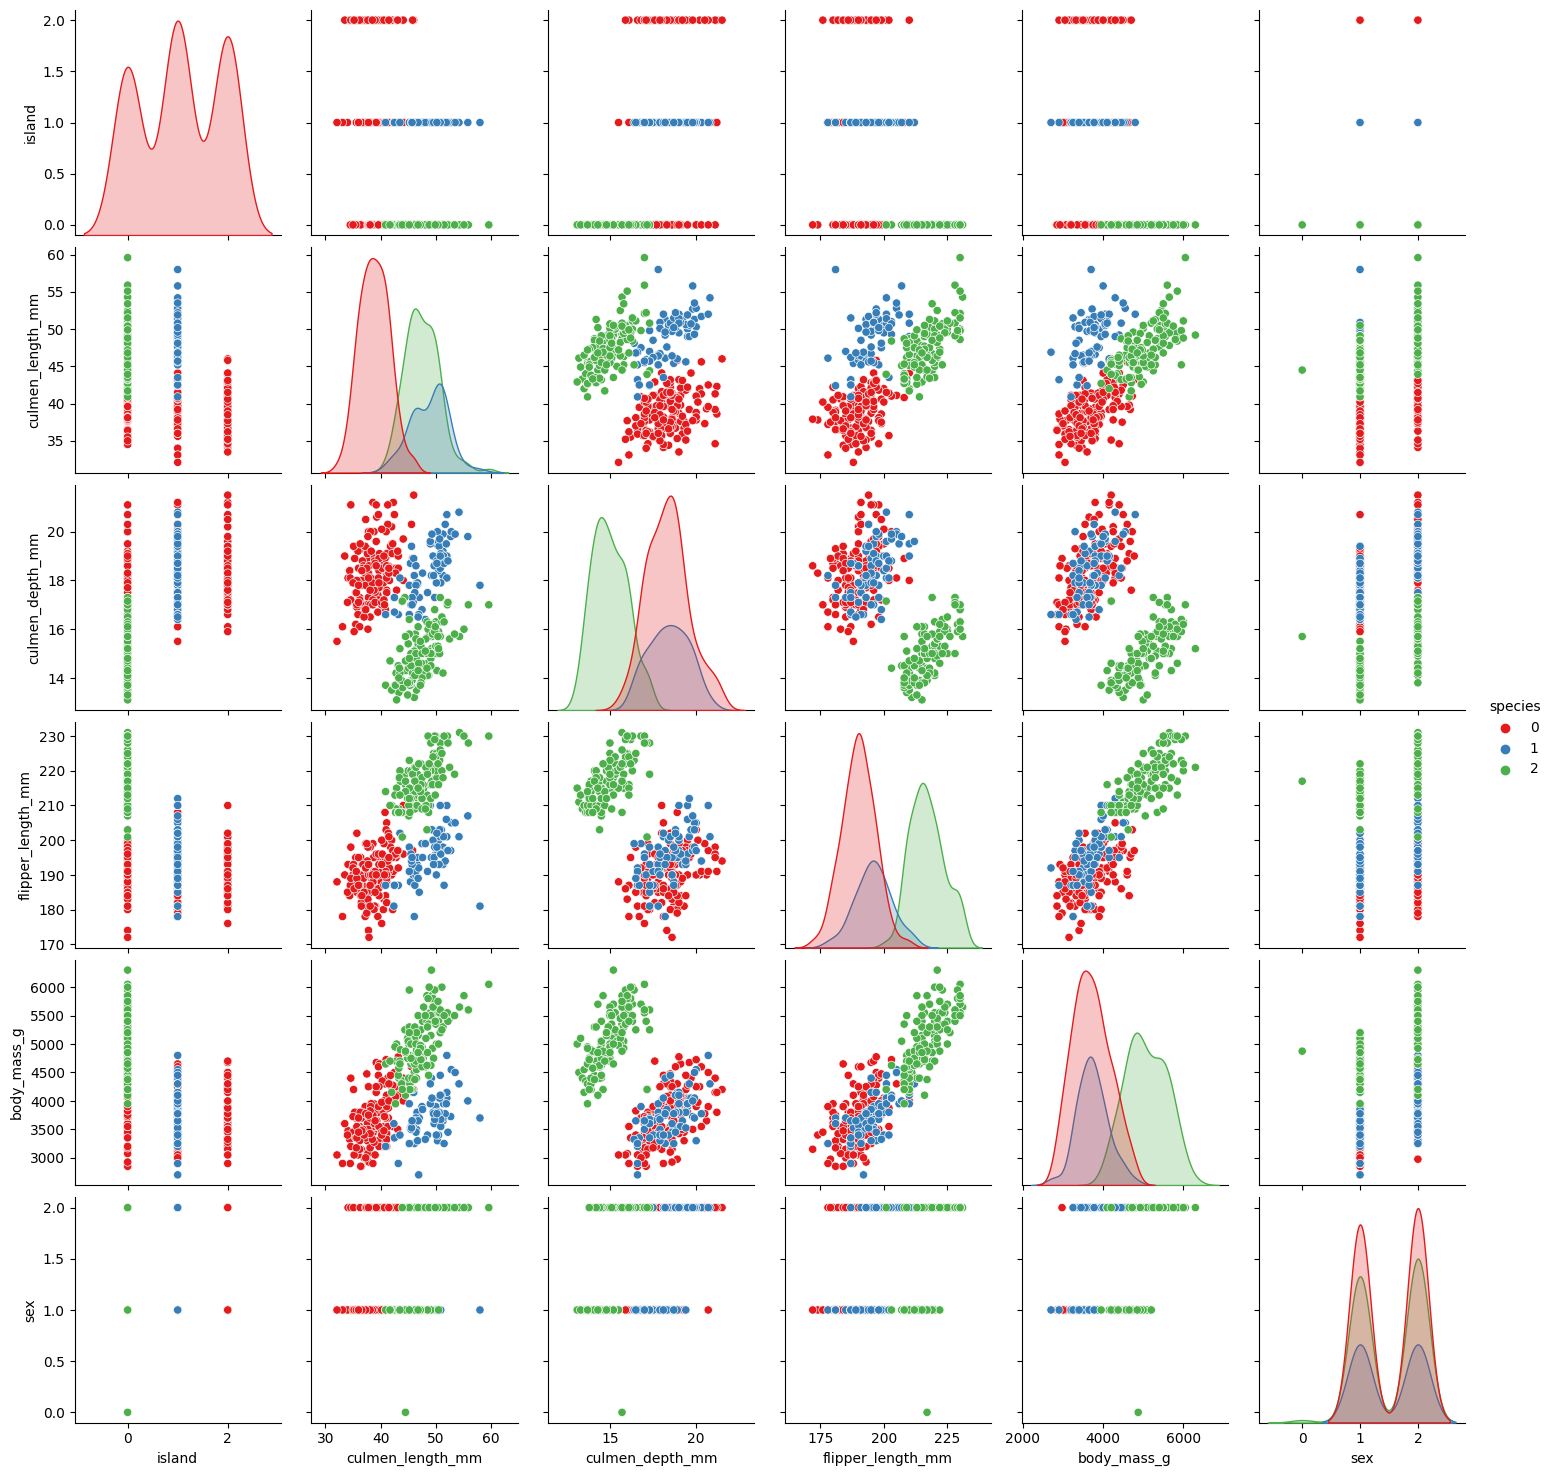

In [19]:
sns.pairplot(df, hue="species", palette="Set1");

In [20]:
df.species.value_counts()


species
0    152
2    124
1     68
Name: count, dtype: int64

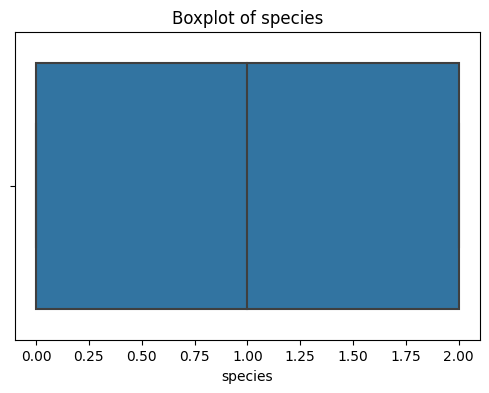

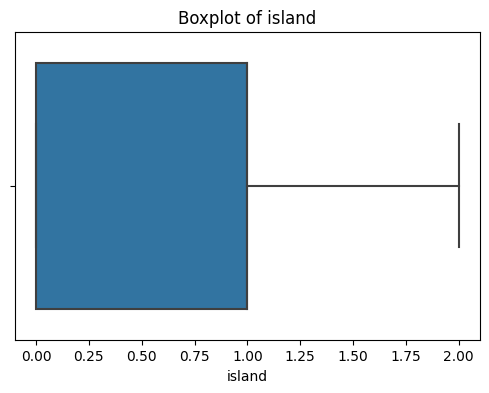

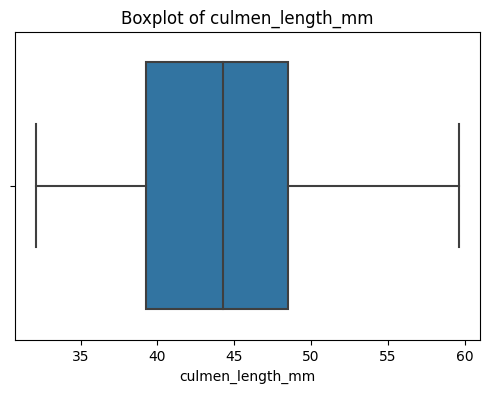

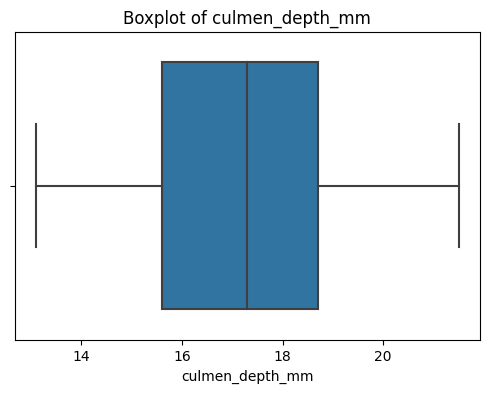

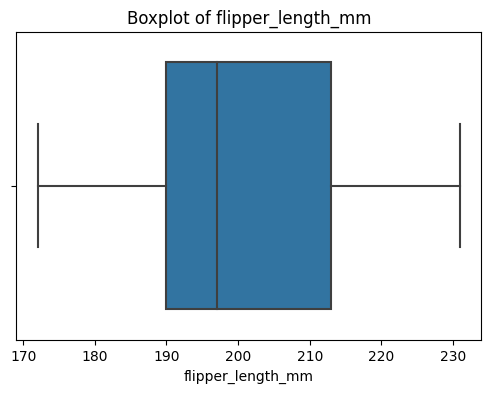

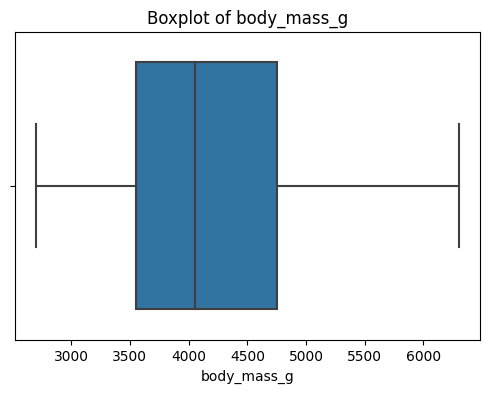

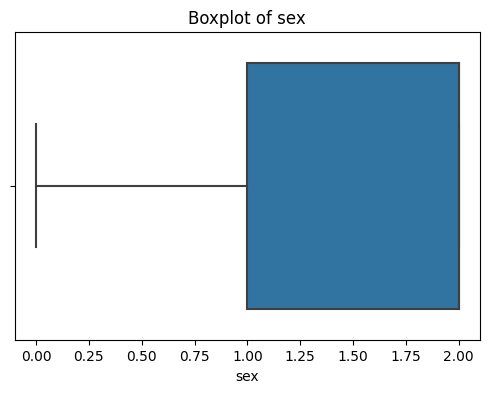

In [21]:
for i in col:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[i])
    plt.title(f'Boxplot of {i}')
    plt.show()

In [22]:
X=df.drop('species',axis=1)
y=df['species']

In [23]:
from sklearn.model_selection import train_test_split as tts

In [24]:
X_train,X_test,y_train,y_test=tts(X,y,test_size=0.2,random_state=42)

In [25]:
print(type(y))
print(y.dtype)
print(y.unique())


<class 'pandas.core.series.Series'>
object
[0 1 2]


In [26]:
y = y.astype(int)


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score

In [28]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()
estimators = [('lr',clf1),('rf',clf2),('knn',clf3)]
for estimator in estimators:
    x = cross_val_score(estimator[1],X_train,y_train,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1204, in fit
    check_classification_targets(y)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/multiclass.py", line 218, in check_classification_targets
    raise ValueError("Unknown label type: %r" % y_type)
ValueError: Unknown label type: 'unknown'


In [ ]:
from sklearn.ensemble import VotingClassifier

In [ ]:
vc = VotingClassifier(estimators=estimators,voting='hard')
x = cross_val_score(vc,X_train,y_train,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

In [ ]:
vc1 = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X_train,y_train,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

In [ ]:
vc1.fit(X_train,y_train)

In [ ]:
y_pred = vc1.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score,r2_score

In [ ]:
print("accuracy score: ", accuracy_score(y_test,y_pred))
print("r2 score: ",r2_score(y_test,y_pred))